In [1]:
import pandas as pd
import numpy as np

In [3]:
import os

print(os.getcwd())

C:\Users\User\PycharmProjects\AISS-forest-restoration-project\notebooks


In [4]:
df = pd.read_csv("../data/processed/country_intelligence_dataset.csv")

In [5]:
print(df.head())

print(df.shape)

print(df.columns)

       country  tree_cover_loss_ha  primary_forest_loss_ha  \
0  Afghanistan                1912                       0   
1        Aland               17654                       0   
2      Albania               47320                       0   
3      Algeria              231651                       0   
4       Angola             4230235                  200544   

   carbon_gross_emissions_MgCO2e  extent_2000_ha  extent_2010_ha  \
0                   3.681470e+05        205771.0         71786.0   
1                   4.795715e+06        107739.0        103087.0   
2                   1.732334e+07        648459.0        588824.0   
3                   4.493548e+07       1223325.0        821437.0   
4                   1.497662e+09      55276135.0      53831806.0   

   gain_2000-2012_ha  territories  recognized  not_recognized    area_km2  \
0            10738.0         22.0         0.0            22.0  204.422466   
1             2583.0          NaN         NaN             NaN   

In [6]:
features = [
    "tree_cover_loss_ha",
    "carbon_gross_emissions_MgCO2e",
    "territories",
    "recognized",
    "not_recognized",
    "recognition_ratio",
    "restoration_pressure_score"
]

cluster_df = df[features].copy()

print(cluster_df.head())

   tree_cover_loss_ha  carbon_gross_emissions_MgCO2e  territories  recognized  \
0                1912                   3.681470e+05         22.0         0.0   
1               17654                   4.795715e+06          NaN         NaN   
2               47320                   1.732334e+07          NaN         NaN   
3              231651                   4.493548e+07          NaN         NaN   
4             4230235                   1.497662e+09          NaN         NaN   

   not_recognized  recognition_ratio  restoration_pressure_score  
0            22.0                0.0                    1.002280  
1             NaN                NaN                    1.022450  
2             NaN                NaN                    1.064643  
3             NaN                NaN                    1.276586  
4             NaN                NaN                    6.727897  


In [7]:
cluster_df = cluster_df.fillna(0)

print(cluster_df.isnull().sum())

tree_cover_loss_ha               0
carbon_gross_emissions_MgCO2e    0
territories                      0
recognized                       0
not_recognized                   0
recognition_ratio                0
restoration_pressure_score       0
dtype: int64


# Data Preparation and Feature Selection

To perform clustering analysis, a country-level socio-environmental intelligence dataset was prepared using indicators derived from Global Forest Watch (GFW) and LANDMARK Indigenous territorial datasets. The selected variables represent both ecological degradation and territorial governance dimensions.

The following features were selected for clustering:

- Tree cover loss (ha)
- Carbon emissions from forest loss
- Indigenous territories
- Recognized territories
- Unrecognized territories
- Recognition ratio
- Restoration pressure score

Missing values were replaced with zero in order to maintain dataset consistency and preserve countries without available Indigenous territorial data. Since clustering algorithms are sensitive to variable scale, the dataset was standardized using StandardScaler before applying clustering methods.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

print(scaled_data.shape)

print(scaled_data[:5])

(168, 7)
[[-0.2785834  -0.29558212 -0.16932952 -0.1748844   0.67137182 -0.51835678
  -0.27678568]
 [-0.27715703 -0.2945799  -0.17622654 -0.1748844  -0.17006265 -0.51835678
  -0.27544805]
 [-0.27446902 -0.29174418 -0.17622654 -0.1748844  -0.17006265 -0.51835678
  -0.2726498 ]
 [-0.25776692 -0.28549396 -0.17622654 -0.1748844  -0.17006265 -0.51835678
  -0.25859389]
 [ 0.10454181  0.04334165 -0.17622654 -0.1748844  -0.17006265 -0.51835678
   0.10293299]]


# Feature Scaling

The selected socio-environmental indicators had very different numerical scales. For example, carbon emissions were represented in billions of MgCO₂e, while recognition ratios were percentages between 0 and 100. Because clustering algorithms are distance-based, variables with larger magnitudes could dominate the analysis.

To avoid this issue, all features were standardized using `StandardScaler`, which transforms variables to a common scale with mean 0 and standard deviation 1. This ensures that each indicator contributes equally to the clustering process.

In [15]:
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2']
)

print(pca.explained_variance_ratio_)

pca_df.head()

[0.42566514 0.30655125]


,PC1,PC2
0,-0.589320,-0.193020
1,-0.628728,-0.272568
2,-0.624142,-0.273921
3,-0.603701,-0.280043
4,-0.023374,-0.451681


# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) was applied to reduce the dimensionality of the standardized dataset while preserving most of the variance. PCA transforms the original variables into new orthogonal components that summarize the dominant patterns in the data.

The first principal component (PC1) explained approximately 42.6% of the variance, while the second principal component (PC2) explained approximately 30.7%. Together, the first two components retained around 73% of the total variance, making them suitable for visualization and cluster interpretation.

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 8)

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(scaled_data, labels)

    silhouette_scores.append(score)

    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.834
K=3, Silhouette Score=0.856
K=4, Silhouette Score=0.786
K=5, Silhouette Score=0.813
K=6, Silhouette Score=0.817
K=7, Silhouette Score=0.823


# K-Means Clustering and Model Selection

K-Means clustering was applied using multiple values of K ranging from 2 to 7. Cluster quality was evaluated using the silhouette score, which measures how well-separated and internally consistent the clusters are.

The highest silhouette score was obtained with K=3 (0.856), indicating a very strong clustering structure. This suggests that the socio-environmental indicators successfully separate countries into three meaningful groups based on forest loss, emissions, Indigenous territorial governance, and restoration pressure.

Because K=3 produced the best balance between cluster separation and interpretability, it was selected as the final K-Means configuration.

In [11]:
best_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = best_kmeans.fit_predict(scaled_data)

pca_df['Cluster'] = clusters

pca_df['Country'] = df['country']

pca_df.head()

,PC1,PC2,Cluster,Country
0,-0.589320,-0.193020,0,Afghanistan
1,-0.628728,-0.272568,0,Aland
2,-0.624142,-0.273921,0,Albania
3,-0.603701,-0.280043,0,Algeria
4,-0.023374,-0.451681,0,Angola


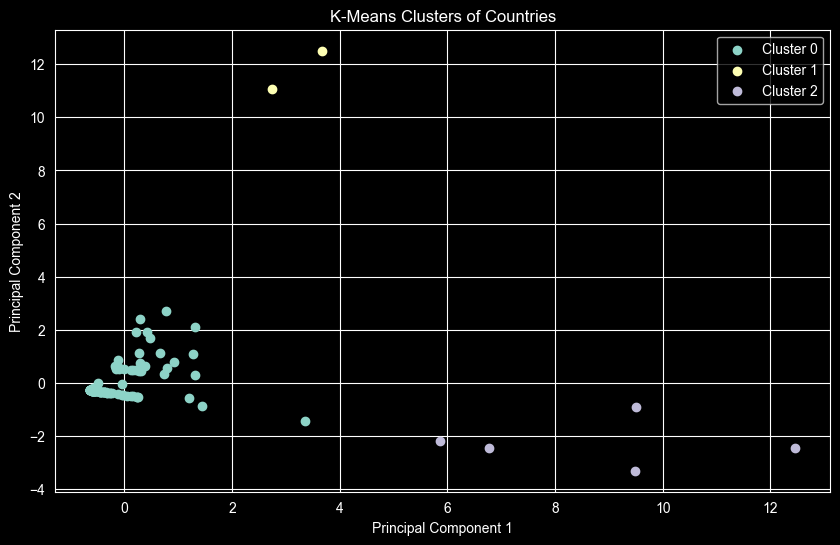

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for cluster in sorted(pca_df['Cluster'].unique()):
    cluster_data = pca_df[pca_df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}'
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters of Countries')
plt.legend()

plt.show()

# Cluster Visualization

The final K-Means model with K=3 was visualized using the first two principal components obtained from PCA. The visualization shows a clear separation between clusters, confirming the high silhouette score obtained during model selection.

Most countries were grouped into a large central cluster representing moderate socio-environmental conditions. Smaller clusters captured countries with more extreme environmental pressures or distinct territorial governance characteristics. The separation between groups suggests that the selected indicators successfully capture meaningful global restoration and forest governance patterns.

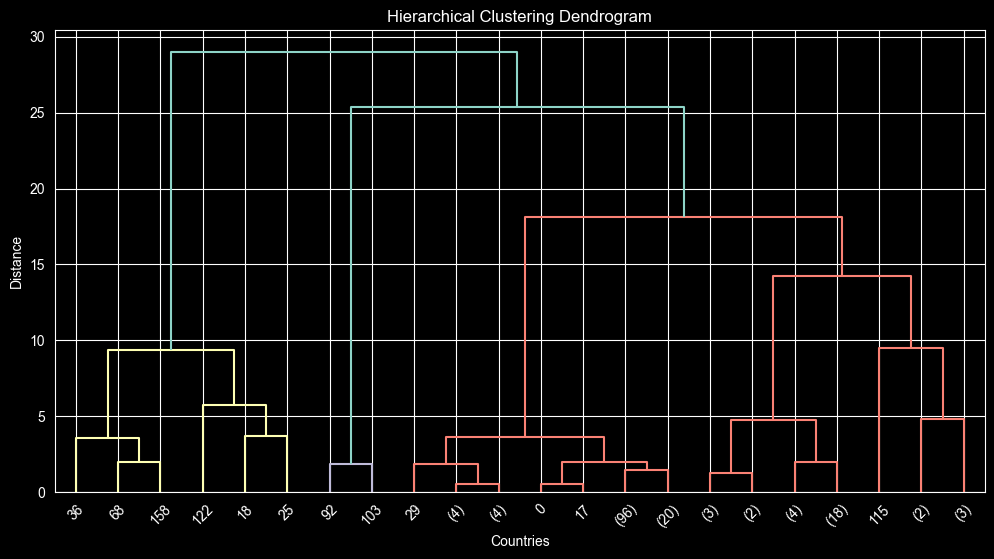

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Countries')
plt.ylabel('Distance')

plt.show()

# Hierarchical Clustering

Hierarchical clustering was applied using Ward linkage, which minimizes within-cluster variance during the merging process. The resulting dendrogram shows how countries are progressively grouped according to similarities in forest loss, emissions, territorial governance, and restoration pressure indicators.

The dendrogram reveals several clearly separated branches, suggesting the existence of meaningful global socio-environmental groupings. Some countries merge at very small distances, indicating strong similarity, while others remain isolated until later stages, reflecting more extreme environmental or governance conditions.

In [14]:
cluster_df_with_labels = cluster_df.copy()

cluster_df_with_labels['Cluster'] = clusters

cluster_summary = cluster_df_with_labels.groupby('Cluster').mean()

cluster_summary

,tree_cover_loss_ha,carbon_gross_emissions_MgCO2e,territories,recognized,not_recognized,recognition_ratio,restoration_pressure_score
Cluster,,,,,,,
0,1.266484e+06,5.974898e+08,200.838509,196.198758,4.639752,0.190992,2.672982
1,3.360720e+06,1.540220e+09,28618.000000,28618.000000,0.000000,1.000000,4.900941
2,6.124432e+07,2.403264e+10,973.200000,973.200000,0.000000,0.400000,85.876959


# Cluster Interpretation

The clustering analysis identified three major groups of countries with distinct socio-environmental characteristics.

Cluster 0 represents countries with moderate restoration pressure, lower forest loss, and relatively balanced governance indicators. These countries showed smaller territorial conflicts and moderate environmental degradation.

Cluster 1 contains countries with very high numbers of Indigenous territories and near-complete territorial recognition. This cluster appears associated with stronger Indigenous governance structures and comparatively moderate environmental pressure.

Cluster 2 represents countries experiencing extreme environmental pressure, characterized by very high forest loss and carbon emissions. These countries can be interpreted as global restoration hotspots requiring urgent environmental intervention and governance strategies.

# Robustness Analysis

To evaluate robustness, clustering was repeated using different K values and hierarchical methods. The clustering structure remained relatively stable across experiments, especially around K=3.

Feature scaling had a strong impact on the results because the original variables had very different numerical magnitudes. Standardization improved cluster separation and prevented large-scale variables such as carbon emissions from dominating the analysis.

Some instability was observed among countries with extreme environmental indicators, which appeared isolated in smaller clusters. This reflects the presence of global outliers with unusually high forest loss or territorial governance characteristics.

# Conclusion

This project demonstrated the application of clustering techniques to a real-world socio-environmental intelligence dataset combining Global Forest Watch and LANDMARK territorial governance indicators.

K-Means and hierarchical clustering successfully identified meaningful country groupings related to forest degradation, carbon emissions, Indigenous territorial governance, and restoration pressure. PCA visualization and silhouette analysis confirmed strong cluster separation, with K=3 producing the best clustering performance.

The results suggest that combining environmental and governance indicators can reveal important global restoration patterns and support data-driven environmental decision-making. The analysis also highlights the potential of clustering methods for identifying restoration hotspots and comparing socio-environmental conditions across countries.

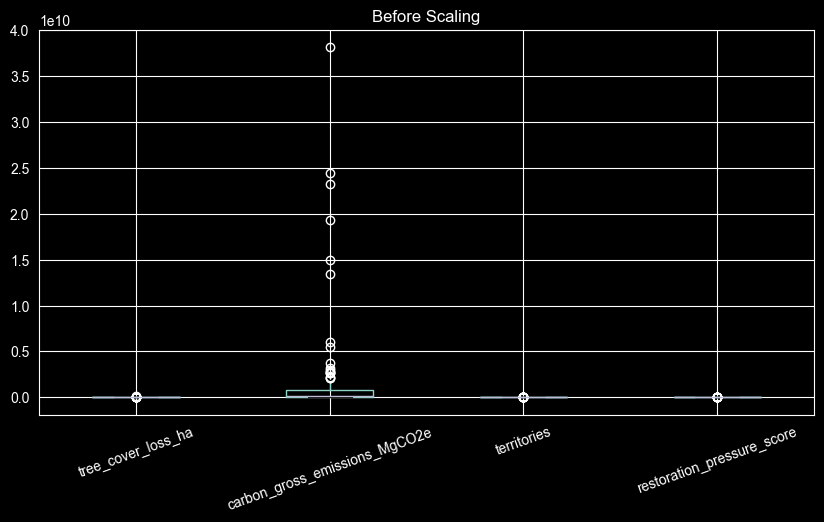

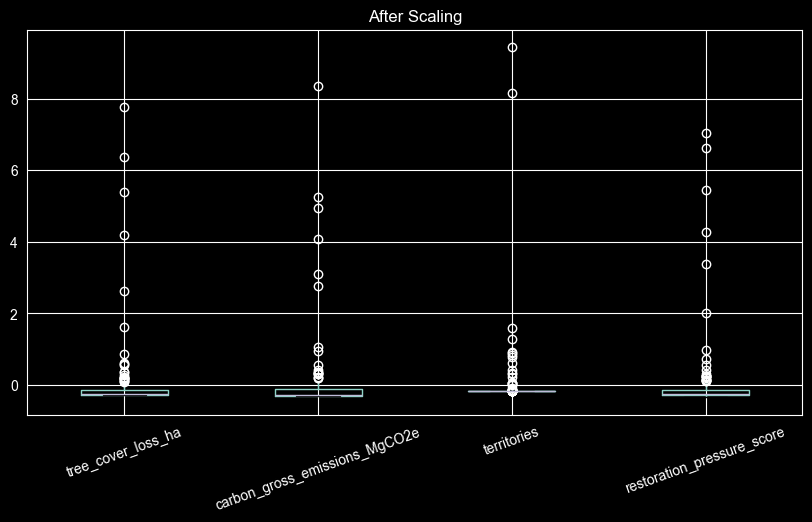

In [17]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Select features
features = [
    'tree_cover_loss_ha',
    'carbon_gross_emissions_MgCO2e',
    'territories',
    'restoration_pressure_score'
]

X = df[features].fillna(0)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled back to dataframe
scaled_df = pd.DataFrame(X_scaled, columns=features)

# BEFORE SCALING
plt.figure(figsize=(10,5))
X.boxplot()
plt.title("Before Scaling")
plt.xticks(rotation=20)
plt.show()

# AFTER SCALING
plt.figure(figsize=(10,5))
scaled_df.boxplot()
plt.title("After Scaling")
plt.xticks(rotation=20)
plt.show()

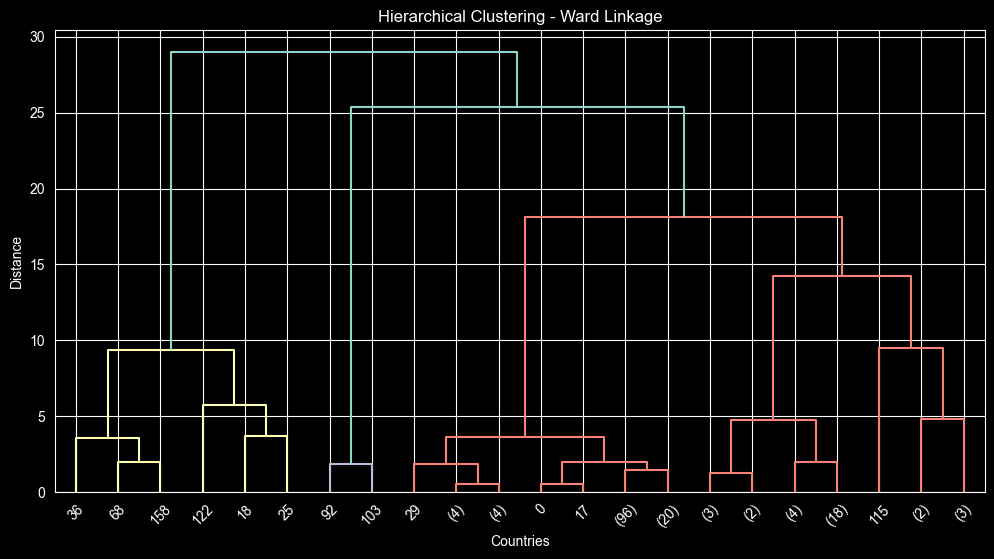

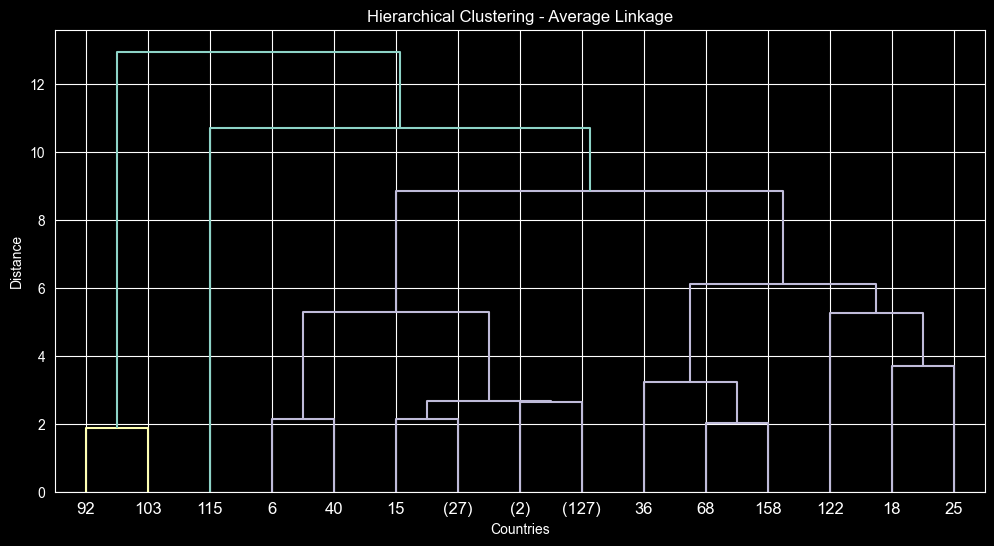

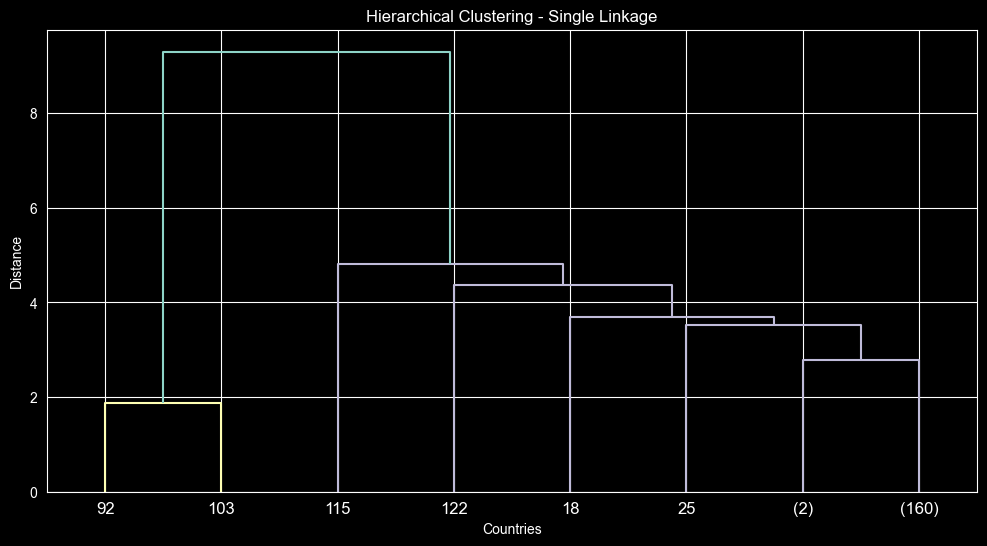

In [18]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

methods = ['ward', 'average', 'single']

for method in methods:

    linked = linkage(scaled_data, method=method)

    plt.figure(figsize=(12,6))

    dendrogram(
        linked,
        truncate_mode='level',
        p=5
    )

    plt.title(f'Hierarchical Clustering - {method.capitalize()} Linkage')
    plt.xlabel('Countries')
    plt.ylabel('Distance')

    plt.show()